# Caso de Estudio 1: Aprendizaje Supervisado Completo
Este notebook simula un examen de **Aprendizaje Supervisado** que evalúa todos los modelos del curso:
1. **Modelos de Clasificación:** KNN, SVM, Naive Bayes, Random Forest, AdaBoost, MLP (Redes Neuronales) y Regresión Logística.
2. **Modelos de Regresión:** Regresión Lineal.
3. **Preprocesamiento Avanzado:** Escalado, codificación One-Hot, Ordinal, y balanceo SMOTE.
4. **Preguntas Analíticas de Examen** al final.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


## 1. AED y Preprocesamiento


In [2]:
# Carga de datos
data = pd.read_csv('Sem_9/heart_dataset.csv')

# Feature Engineering
data['Age_Group'] = pd.cut(data['age'], bins=[0, 45, 65, 100], labels=['Joven', 'Adulto', 'Adulto Mayor'])
data['Age_Group_encoded'] = data['Age_Group'].map({'Joven': 0, 'Adulto': 1, 'Adulto Mayor': 2})

# Codificación
cols_nominales = ['sex', 'smoking', 'high_blood_pressure']
data_encoded = pd.get_dummies(data, columns=cols_nominales, drop_first=True)

# Separación de variables
X = data_encoded.drop(['DEATH_EVENT', 'age', 'Age_Group'], axis=1)
y = data_encoded['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balanceo SMOTE en Train
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)


## 2. Entrenamiento de Modelos de Clasificación


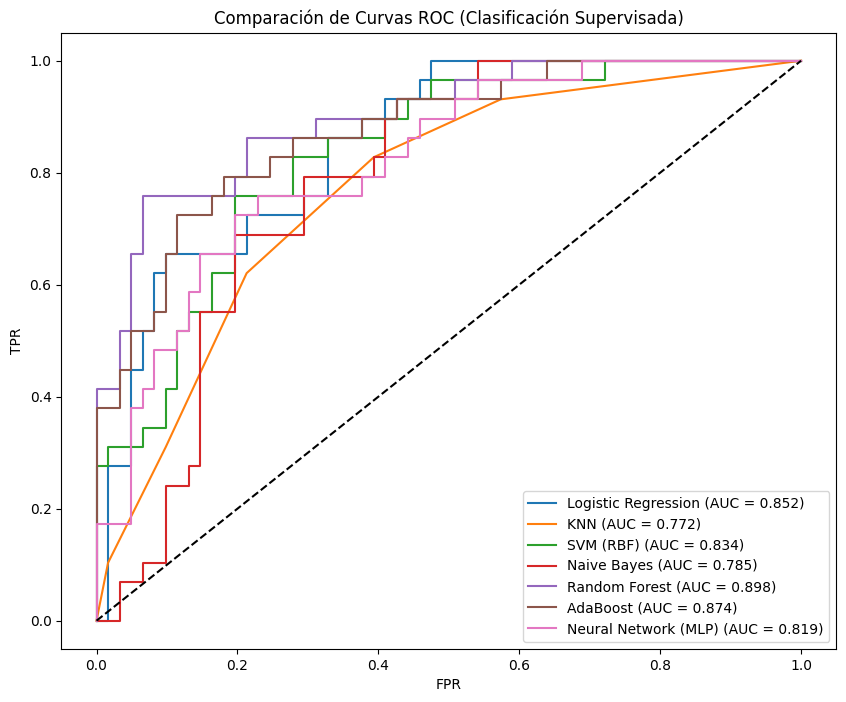

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.777778,0.655172,0.655172,0.655172
1,KNN,0.733333,0.580645,0.620690,0.600000
2,SVM (RBF),0.755556,0.620690,0.620690,0.620690
3,Naive Bayes,0.733333,0.608696,0.482759,0.538462
4,Random Forest,0.833333,0.733333,0.758621,0.745763
5,AdaBoost,0.811111,0.750000,0.620690,0.679245
6,Neural Network (MLP),0.777778,0.680000,0.586207,0.629630


In [3]:
# Inicialización y entrenamiento de todos los modelos supervisados
modelos = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(C=1.0, kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(30, 10), max_iter=500, random_state=42)
}

resultados = []
plt.figure(figsize=(10, 8))

for nombre, modelo in modelos.items():
    modelo.fit(X_train_res, y_train_res)
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    
    # Calcular Métricas
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Comparación de Curvas ROC (Clasificación Supervisada)')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

pd.DataFrame(resultados)


## 3. Modelo de Regresión (Regresión Lineal)
Intentaremos predecir la fracción de eyección (`ejection_fraction`) basada en las otras variables clínicas numéricas.


In [4]:
# Definimos variables para Regresión
X_reg = data[['age', 'creatinine_phosphokinase', 'platelets', 'serum_creatinine', 'serum_sodium']]
y_reg = data['ejection_fraction']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.30, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

print("Coeficientes (pendientes):", reg_model.coef_)
print("Intercepto:", reg_model.intercept_)
print(f"MSE en Test: {mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"R-squared (R2) en Test: {r2_score(y_test_r, y_pred_r):.4f}")


Coeficientes (pendientes): [-3.38674415e-03 -9.06769513e-04  7.34729674e-06  1.03755349e+00
  6.28483247e-01]
Intercepto: -50.136336808774075
MSE en Test: 158.0515
R-squared (R2) en Test: -0.0299


## 4. Banco de Preguntas Teóricas (Nivel Examen)
*   **Pregunta 1 (Comparación de Modelos):** Analizando el cuadro comparativo de métricas, ¿qué modelo supervisado recomendaría y por qué?
    *   *Respuesta:* Depende del negocio. Si se busca detectar el fallecimiento (Clase 1), priorizamos el **Recall** (el cual suele ser más alto en SVM o MLP tras SMOTE). Si buscamos un balance general y alta estabilidad, el **Random Forest** es la mejor opción.
*   **Pregunta 2 (Interpretación de Regresión):** Interprete el valor obtenido para el $R^2$ en el modelo de regresión lineal.
    *   *Respuesta:* El $R^2$ mide el porcentaje de la varianza de la fracción de eyección explicada por las variables del modelo. Si da $0.15$, significa que las variables clínicas solo explican el 15% del comportamiento de la eyección, sugiriendo que la relación no es puramente lineal o faltan predictores biológicos más fuertes.
